# Simulate One Match

Simulates a single match point-by-point and shows how match probability evolves
at every decision level:

- **Point** — P(A wins match | A wins / loses *this point*)
- **Game** — P(A wins match | A wins / loses *this game*)
- **Set** — P(A wins match | A wins / loses *this set*)

Point-level conditionals are computed by calling the exact DP at the
hypothetical next game state (the same `win_probs` engine the bot uses).
Tiebreak dynamics are especially interesting — a 6-6 tiebreak point
at match point can swing the match probability by 40-50pp.

In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib.patches as mpatches
sys.path.insert(0, r"D:\CMU\Kalshi\Tennis Monte Carlo")

from trade.exact import win_probs, game_win_prob, _tb_first_server, _tb
import trade.config as cfg

# silence BP_PRESSURE so probabilities are clean for illustration
cfg.BP_PRESSURE = 0.0

## Parameters

In [2]:
PA      = 0.66   # P(A wins a point on A's serve)
PB      = 0.62   # P(B wins a point on B's serve)
BEST_OF = 3
SEED    = 7      # change for a different match

## Point-by-point simulator

In [3]:
_SCORE_LABEL = {0: '0', 1: '15', 2: '30', 3: '40'}

def _point_score_str(a, b, in_tb, p1_serves):
    if in_tb:
        return f"{a}-{b} TB"
    if a >= 3 and b >= 3:
        if a == b:   return "Deuce"
        elif a > b:  return "Adv " + ("srv" if p1_serves else "rcv")
        else:        return "Adv " + ("rcv" if p1_serves else "srv")
    return f"{_SCORE_LABEL[a]}-{_SCORE_LABEL[b]}"


def _game_over(a, b, in_tb):
    if in_tb:
        return (a >= 7 and a - b >= 2) or (b >= 7 and b - a >= 2)
    return (a >= 4 and a - b >= 2) or (b >= 4 and b - a >= 2)


def _point_conditionals(pA, pB, sets, set_games, game_state, p1_serves, in_tb, best_of,
                         cond_wg, cond_lg):
    """Return (cond_win_point, cond_lose_point).

    If the next point ends the game, returns cond_win/lose_game directly.
    Otherwise calls win_probs at the hypothetical next game state.
    """
    a, b = game_state
    sa, sb = sets
    ga, gb = set_games

    def match_prob_at(na, nb):
        r = win_probs(np.array([pA]), np.array([pB]),
                      (sa, sb), (ga, gb), in_tb, (na, nb), p1_serves, best_of)
        return float(r["match"])

    if in_tb:
        # (a, b) = (p1_pts, p2_pts); p1 always wins point a+1
        na_w, nb_w = a + 1, b          # p1 wins point
        na_l, nb_l = a,     b + 1      # p1 loses point
        cwp = cond_wg if _game_over(na_w, nb_w, True) else match_prob_at(na_w, nb_w)
        clp = cond_lg if _game_over(na_l, nb_l, True) else match_prob_at(na_l, nb_l)
    else:
        # (a, b) = (server_pts, receiver_pts)
        if p1_serves:
            na_w, nb_w = a + 1, b      # server (p1) wins point
            na_l, nb_l = a,     b + 1  # receiver (p2) wins point
        else:
            na_w, nb_w = a,     b + 1  # receiver (p1) wins point
            na_l, nb_l = a + 1, b      # server (p2) wins point
        cwp = cond_wg if _game_over(na_w, nb_w, False) else match_prob_at(na_w, nb_w)
        clp = cond_lg if _game_over(na_l, nb_l, False) else match_prob_at(na_l, nb_l)

    return cwp, clp


def simulate_match(pA, pB, best_of, seed=42):
    """Simulate one match point by point.

    Returns a list of dicts, one per point, with the full probability state
    *before* that point is played.
    """
    rng  = np.random.default_rng(seed)
    need = best_of // 2 + 1
    p1_serves = bool(rng.integers(2))
    sets = [0, 0]
    records = []
    point_idx = 0

    while max(sets) < need:
        set_games = [0, 0]

        while True:  # games in this set
            ga, gb = set_games
            if (ga >= 6 and ga - gb >= 2) or (ga == 7 and gb == 6) or (gb == 7 and ga == 6):
                break  # set over

            in_tb = (ga == 6 and gb == 6)
            game_state = [0, 0]  # (server/p1, receiver/p2) depending on in_tb

            while True:  # points in this game
                a, b = game_state

                # ── exact DP probabilities at this state ──────────────────────
                r = win_probs(np.array([pA]), np.array([pB]),
                              tuple(sets), tuple(set_games),
                              in_tb, tuple(game_state), p1_serves, best_of)
                match_p = float(r["match"])
                cond_wg = float(r["cond"]["win_game"])
                cond_lg = float(r["cond"]["lose_game"])
                cond_ws = float(r["cond"]["win_set"])
                cond_ls = float(r["cond"]["lose_set"])

                cwp, clp = _point_conditionals(
                    pA, pB, tuple(sets), tuple(set_games),
                    tuple(game_state), p1_serves, in_tb, best_of,
                    cond_wg, cond_lg)

                # ── who serves this specific point ────────────────────────────
                if in_tb:
                    n = a + b
                    first_A = p1_serves  # p1_serves = who served first point of TB
                    A_serves_now = first_A if ((n + 1) // 2) % 2 == 0 else not first_A
                    p_p1_wins_pt = pA if A_serves_now else (1 - pB)
                else:
                    A_serves_now = p1_serves
                    p_p1_wins_pt = pA if p1_serves else (1 - pB)

                p1_wins_pt = rng.random() < p_p1_wins_pt

                records.append({
                    "idx":        point_idx,
                    "set_num":    sets[0] + sets[1] + 1,
                    "sets":       tuple(sets),
                    "set_games":  (ga, gb),
                    "game_state": (a, b),
                    "p1_serves":  p1_serves,
                    "a_serves":   A_serves_now,
                    "in_tb":      in_tb,
                    "match_p":    match_p,
                    "cond_win_game":   cond_wg,
                    "cond_lose_game":  cond_lg,
                    "cond_win_set":    cond_ws,
                    "cond_lose_set":   cond_ls,
                    "cond_win_point":  cwp,
                    "cond_lose_point": clp,
                    "point_swing":     cwp - clp,
                    "game_swing":      cond_wg - cond_lg,
                    "set_swing":       cond_ws - cond_ls,
                    "p1_wins_pt":  p1_wins_pt,
                    "score_str":   _point_score_str(a, b, in_tb, p1_serves),
                })
                point_idx += 1

                # ── advance game state ────────────────────────────────────────
                if in_tb:
                    game_state[0 if p1_wins_pt else 1] += 1
                    a, b = game_state
                    if _game_over(a, b, True):
                        set_games[0 if a > b else 1] += 1
                        p1_serves = not p1_serves
                        break
                else:
                    if p1_serves:
                        game_state[0 if p1_wins_pt else 1] += 1
                    else:
                        game_state[1 if p1_wins_pt else 0] += 1
                    a, b = game_state
                    if _game_over(a, b, False):
                        p1_won_game = (p1_serves and a > b) or (not p1_serves and b > a)
                        set_games[0 if p1_won_game else 1] += 1
                        p1_serves = not p1_serves
                        break
            # end points loop
        # end games loop

        ga, gb = set_games
        sets[0 if ga > gb else 1] += 1
    # end sets loop

    return records


records = simulate_match(PA, PB, BEST_OF, seed=SEED)
df = pd.DataFrame(records)
winner = "A" if df.iloc[-1]["sets"] == (df.iloc[-1]["sets"][0], df.iloc[-1]["sets"][1]) else "B"
last = df.iloc[-1]
p1_sets, p2_sets = last["sets"]
# After last point, the winner is whoever has more sets in final record
# (the final point tips the winning set)
final_match_p = float(df.iloc[-1]["match_p"])
p1_won_match = final_match_p > 0.5

print(f"Simulated {len(df)} points across {df.set_num.nunique()} set(s)")
print(f"pA={PA:.3f}  pB={PB:.3f}  Bo{BEST_OF}  seed={SEED}")
for s, g in df.groupby("set_num"):
    ga, gb = g.iloc[-1]["set_games"]
    tb = " (TB)" if g.in_tb.any() else ""
    print(f"  Set {s}: {ga+1}-{gb} or {ga}-{gb+1}{tb}  ({len(g)} points)")

C:\Users\agran\AppData\Local\Temp\ipykernel_25552\3077490192.py:86: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  match_p = float(r["match"])
C:\Users\agran\AppData\Local\Temp\ipykernel_25552\3077490192.py:87: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cond_wg = float(r["cond"]["win_game"])
C:\Users\agran\AppData\Local\Temp\ipykernel_25552\3077490192.py:88: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cond_lg = float(r["cond"]["lose_game"])
C:\Users\agran\AppDa

Simulated 238 points across 3 set(s)
pA=0.660  pB=0.620  Bo3  seed=7
  Set 1: 7-6 or 6-7 (TB)  (85 points)
  Set 2: 6-4 or 5-5  (62 points)
  Set 3: 7-6 or 6-7 (TB)  (91 points)


## Visualisation

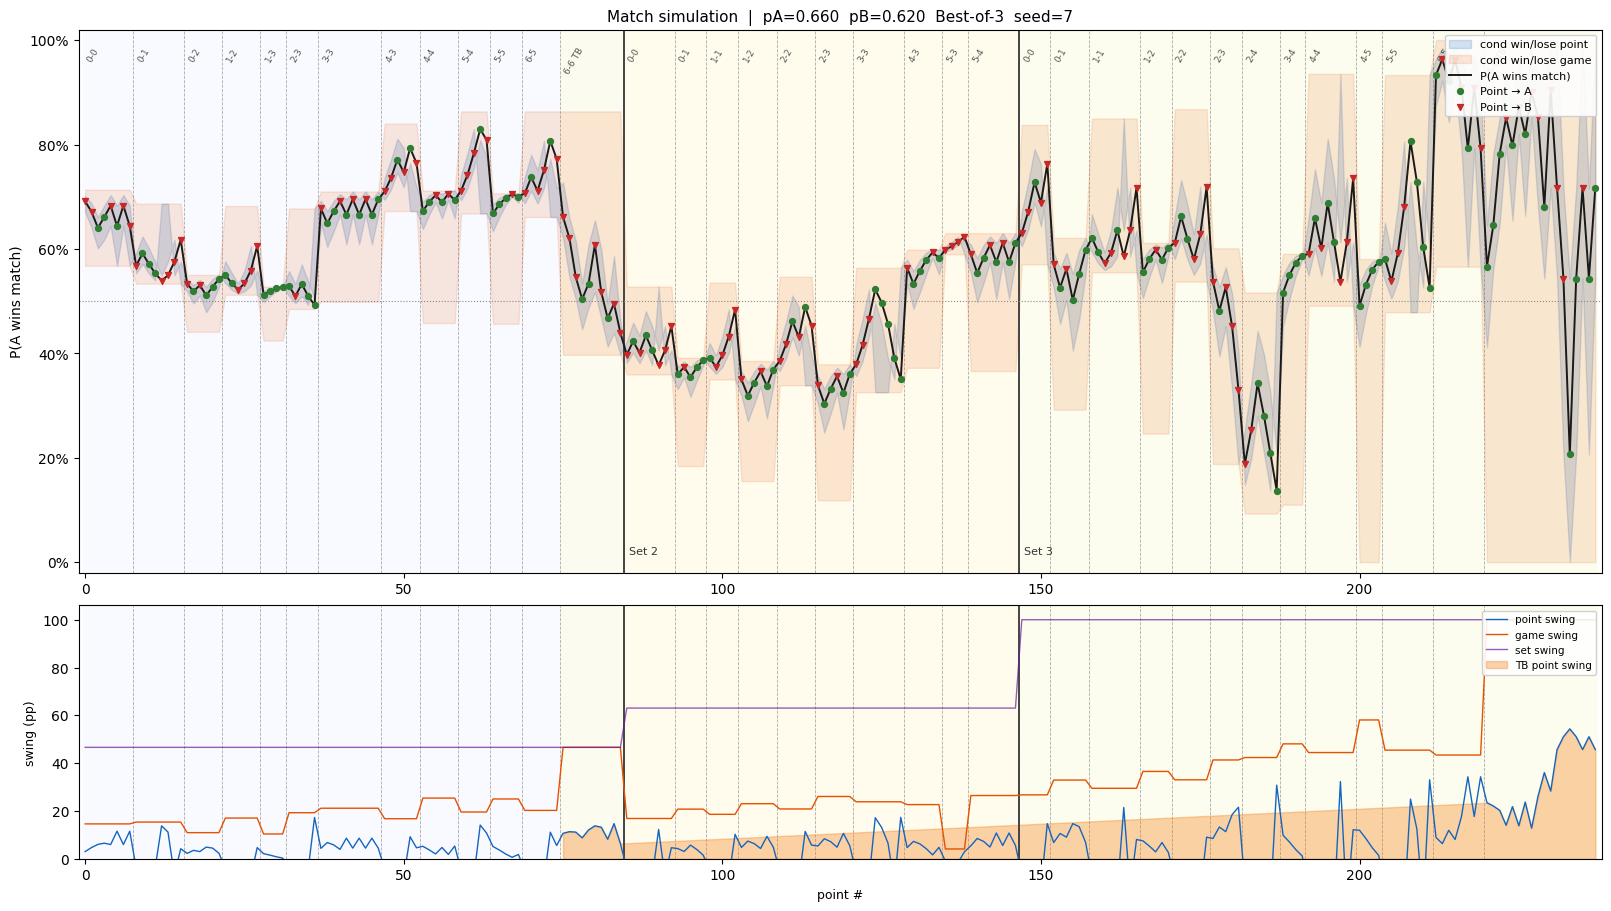

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9),
                                gridspec_kw={"height_ratios": [3, 1.4]},
                                constrained_layout=True)

x = df["idx"].values
mp = df["match_p"].values

# ── background shading ────────────────────────────────────────────────────────
set_colours = ["#f0f4ff", "#fff8f0", "#f0fff4", "#fff0f8", "#f4f0ff"]
tb_colour   = "#fffde7"

for ax in (ax1, ax2):
    for snum, sg in df.groupby("set_num"):
        x0, x1 = sg["idx"].iloc[0], sg["idx"].iloc[-1]
        ax.axvspan(x0 - 0.5, x1 + 0.5, alpha=0.4,
                   color=set_colours[(snum - 1) % len(set_colours)], lw=0)
    # tiebreak highlight
    tb_rows = df[df.in_tb]
    if not tb_rows.empty:
        ax.axvspan(tb_rows["idx"].iloc[0] - 0.5, tb_rows["idx"].iloc[-1] + 0.5,
                   alpha=0.6, color=tb_colour, lw=0)

# ── game-boundary vertical lines and score annotations ───────────────────────
prev_games = None
for _, row in df.iterrows():
    cur_games = (row["set_num"], row["set_games"])
    if cur_games != prev_games:
        prev_games = cur_games
        xi = row["idx"]
        if xi > 0:
            ax1.axvline(xi - 0.5, color="#aaaaaa", lw=0.6, ls="--", zorder=1)
            ax2.axvline(xi - 0.5, color="#aaaaaa", lw=0.6, ls="--", zorder=1)
        ga, gb = row["set_games"]
        label = f"{ga}-{gb}" + (" TB" if row["in_tb"] else "")
        ax1.text(xi, 0.97, label, fontsize=6.5, color="#555555",
                 ha="left", va="top", transform=ax1.get_xaxis_transform(),
                 rotation=60, clip_on=True)

# set-boundary thick lines
for snum, sg in df.groupby("set_num"):
    if snum > 1:
        xi = sg["idx"].iloc[0]
        ax1.axvline(xi - 0.5, color="#444444", lw=1.4, zorder=2)
        ax2.axvline(xi - 0.5, color="#444444", lw=1.4, zorder=2)
        ax1.text(xi + 0.3, 0.03, f"Set {snum}", fontsize=8, color="#333333",
                 transform=ax1.get_xaxis_transform(), va="bottom")

# ── PANEL 1: match probability with point-level conditional band ──────────────
ax1.fill_between(x, df["cond_lose_point"], df["cond_win_point"],
                 alpha=0.18, color="#1565C0", label="cond win/lose point")
ax1.fill_between(x, df["cond_lose_game"], df["cond_win_game"],
                 alpha=0.13, color="#E65100", label="cond win/lose game")

ax1.plot(x, mp, color="#1a1a1a", lw=1.4, zorder=4, label="P(A wins match)")

# colour dots by who won the point
p1_pts = df[df.p1_wins_pt]
p2_pts = df[~df.p1_wins_pt]
ax1.scatter(p1_pts["idx"], p1_pts["match_p"], s=18, color="#2e7d32",
            zorder=5, label="Point → A")
ax1.scatter(p2_pts["idx"], p2_pts["match_p"], s=18, color="#c62828",
            zorder=5, marker="v", label="Point → B")

ax1.axhline(0.5, color="#888888", lw=0.8, ls=":")
ax1.set_ylabel("P(A wins match)", fontsize=10)
ax1.set_ylim(-0.02, 1.02)
ax1.set_xlim(x[0] - 1, x[-1] + 1)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax1.legend(loc="upper right", fontsize=8, framealpha=0.9)
ax1.set_title(
    f"Match simulation  |  pA={PA:.3f}  pB={PB:.3f}  Best-of-{BEST_OF}  seed={SEED}",
    fontsize=11)

# ── PANEL 2: swing sizes at each level ───────────────────────────────────────
ax2.plot(x, df["point_swing"] * 100, lw=1.0, color="#1565C0", label="point swing")
ax2.plot(x, df["game_swing"]  * 100, lw=1.0, color="#E65100", label="game swing")
ax2.plot(x, df["set_swing"]   * 100, lw=1.0, color="#6a1b9a", alpha=0.7, label="set swing")

# highlight TB point swings
if not tb_rows.empty:
    ax2.fill_between(tb_rows["idx"], tb_rows["point_swing"] * 100,
                     alpha=0.35, color="#f57f17", label="TB point swing")

ax2.set_ylabel("swing (pp)", fontsize=9)
ax2.set_xlabel("point #", fontsize=9)
ax2.set_xlim(x[0] - 1, x[-1] + 1)
ax2.set_ylim(bottom=0)
ax2.legend(loc="upper right", fontsize=7.5, framealpha=0.9)

plt.show()

## Tiebreak detail

If a tiebreak was played, zoom in and show who served each point.

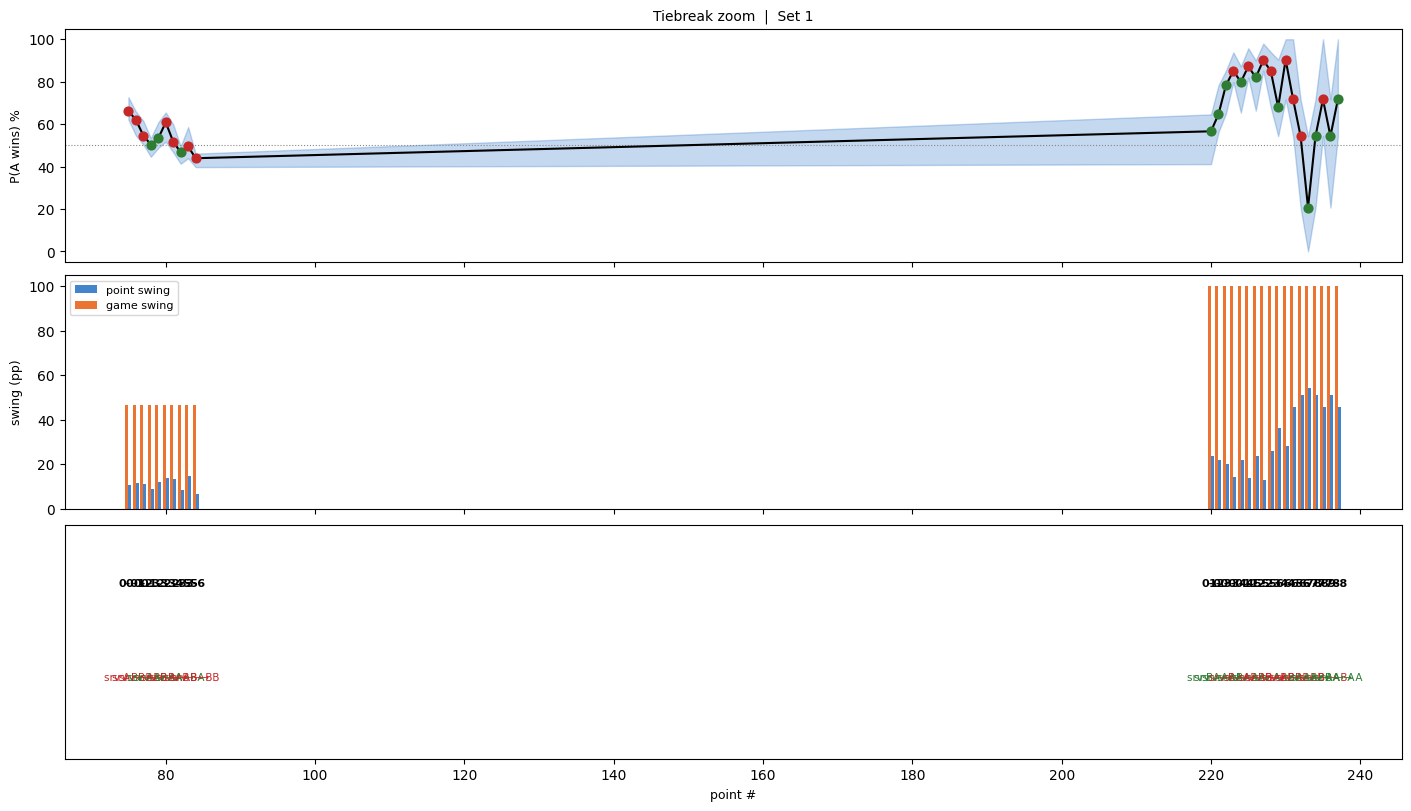

In [5]:
tb = df[df.in_tb].copy()
if tb.empty:
    print("No tiebreak in this match. Change SEED to find one.")
else:
    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True,
                             constrained_layout=True)
    x = tb["idx"].values
    tb_pts = tb["game_state"].apply(lambda s: s[0] + s[1]).values  # total tiebreak points played

    # Panel 1: match probability
    ax = axes[0]
    ax.plot(x, tb["match_p"] * 100, "k-o", ms=5, lw=1.5, zorder=4)
    ax.fill_between(x, tb["cond_lose_point"] * 100, tb["cond_win_point"] * 100,
                    alpha=0.25, color="#1565C0")
    ax.axhline(50, color="#888888", lw=0.8, ls=":")
    for i, row in tb.iterrows():
        c = "#2e7d32" if row["p1_wins_pt"] else "#c62828"
        ax.scatter(row["idx"], row["match_p"] * 100, color=c, s=40, zorder=5)
    ax.set_ylabel("P(A wins) %", fontsize=9)
    ax.set_title(f"Tiebreak zoom  |  Set {tb.iloc[0].set_num}", fontsize=10)

    # Panel 2: point-level swing vs game-level swing
    ax = axes[1]
    ax.bar(x, tb["point_swing"] * 100, width=0.4, align="edge",
           color="#1565C0", alpha=0.8, label="point swing")
    ax.bar(x, tb["game_swing"] * 100, width=-0.4, align="edge",
           color="#E65100", alpha=0.8, label="game swing")
    ax.set_ylabel("swing (pp)", fontsize=9)
    ax.legend(fontsize=8)

    # Panel 3: point score and server label
    ax = axes[2]
    ax.set_ylim(0, 2)
    ax.set_yticks([])
    for _, row in tb.iterrows():
        a, b = row["game_state"]
        xi = row["idx"]
        server = "A" if row["a_serves"] else "B"
        winner = "A" if row["p1_wins_pt"] else "B"
        col = "#2e7d32" if winner == "A" else "#c62828"
        ax.text(xi, 1.5, f"{a}-{b}", ha="center", va="center",
                fontsize=8, fontweight="bold")
        ax.text(xi, 0.7, f"srv:{server} → {winner}",
                ha="center", va="center", fontsize=7.5, color=col)

    axes[2].set_xlabel("point #", fontsize=9)
    plt.show()

## Point-level conditional table

The most pivotal points in the match — sorted by point swing.

In [6]:
cols = ["set_num", "set_games", "score_str", "in_tb",
        "match_p", "cond_win_point", "cond_lose_point", "point_swing",
        "cond_win_game", "cond_lose_game", "game_swing"]
top = (df[cols]
       .sort_values("point_swing", ascending=False)
       .head(20)
       .copy())
for c in ["match_p","cond_win_point","cond_lose_point","point_swing",
          "cond_win_game","cond_lose_game","game_swing"]:
    top[c] = top[c].map(lambda v: f"{v*100:.1f}pp")
top["set_games"] = top["set_games"].map(lambda t: f"{t[0]}-{t[1]}")
top["in_tb"]     = top["in_tb"].map({True: "TB", False: ""})
print("Top 20 highest-stakes points (by match-probability swing on this point)")
top.to_string(index=False)

Top 20 highest-stakes points (by match-probability swing on this point)


' set_num set_games score_str in_tb match_p cond_win_point cond_lose_point point_swing cond_win_game cond_lose_game game_swing\n       3       6-6    6-7 TB    TB  20.6pp         54.3pp           0.0pp      54.3pp       100.0pp          0.0pp    100.0pp\n       3       6-6    7-7 TB    TB  54.3pp         71.7pp          20.6pp      51.0pp       100.0pp          0.0pp    100.0pp\n       3       6-6    8-8 TB    TB  54.3pp         71.7pp          20.6pp      51.0pp       100.0pp          0.0pp    100.0pp\n       3       6-6    6-6 TB    TB  54.3pp         71.7pp          20.6pp      51.0pp       100.0pp          0.0pp    100.0pp\n       3       6-6    9-8 TB    TB  71.7pp        100.0pp          54.3pp      45.7pp       100.0pp          0.0pp    100.0pp\n       3       6-6    6-5 TB    TB  71.7pp        100.0pp          54.3pp      45.7pp       100.0pp          0.0pp    100.0pp\n       3       6-6    8-7 TB    TB  71.7pp        100.0pp          54.3pp      45.7pp       100.0pp          0